In [4]:
import pandas as pd
import numpy as np

In [ ]:
!pip install scikit-multilearn
!pip install -U sentence-transformers
!pip install matplotlib

In [6]:
df = pd.read_csv('/Users/anikaraghavan/Downloads/recipes-with-nutrition.csv')[['recipe_name', 'ingredients', 'cuisine_type']]
df.head()

,recipe_name,ingredients,cuisine_type
0,Classic Cabbage Slaw with Grandmother Shinn's ...,"[{""food"":""kosher salt"",""text"":""1 tablespoon ko...","[""american""]"
1,Black Bean Soup,"[{""food"":""ham steak"",""text"":""1 pound fully coo...","[""american""]"
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,"[{""food"":""firm tofu"",""text"":""1 pound medium to...","[""asian""]"
3,Fried Chicken Banh Mi,"[{""food"":""oil"",""text"":""Neutral oil, for frying...","[""south east asian""]"
4,The Macaron Frappé,"[{""food"":""macaron"",""text"":""1 macaron (about ½ ...","[""french""]"


In [7]:
import json
df['ingredients'] = df['ingredients'].apply(lambda x: [e['food'] for e in json.loads(x)])

In [8]:
df['cuisine_type'] = df['cuisine_type'].apply(json.loads)

In [9]:
df.head()

,recipe_name,ingredients,cuisine_type
0,Classic Cabbage Slaw with Grandmother Shinn's ...,"[kosher salt, water, green cabbage, carrots, s...",[american]
1,Black Bean Soup,"[ham steak, olive oil, onion, garlic, water, c...",[american]
2,Eat for Eight Bucks: Tofu with Tomatoes and Ci...,"[firm tofu, canola oil, scallions, piece of gi...",[asian]
3,Fried Chicken Banh Mi,"[oil, rice vinegar, granulated sugar, kosher s...",[south east asian]
4,The Macaron Frappé,"[macaron, milk, vanilla ice cream, ice]",[french]


In [10]:
df.dtypes

recipe_name        str
ingredients     object
cuisine_type    object
dtype: object

<Axes: xlabel='cuisine_type'>

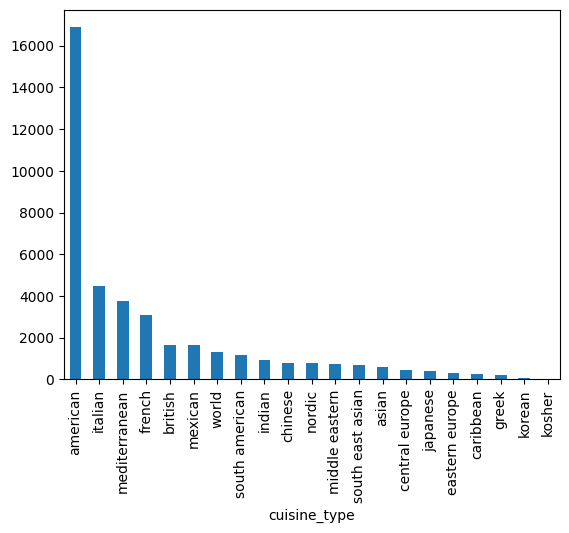

In [42]:
import matplotlib.pyplot as plt
label_counts = df['cuisine_type'].explode().value_counts()
label_counts.plot(kind='bar')

In [11]:
embed_str_format = """
Recipe: {recipe}
Ingredients: {ingredients}
"""
recipe_texts = []
for i in range(len(df)):
    row = df.iloc[i]
    recipe = row['recipe_name']
    ingredients = row['ingredients']
    embed_str = embed_str_format.format(recipe=recipe, ingredients=' '.join(ingredients))
    recipe_texts.append(embed_str)

In [12]:
print(recipe_texts[0])


Recipe: Classic Cabbage Slaw with Grandmother Shinn's Dressing
Ingredients: kosher salt, water, green cabbage, carrots, scallions, eggs, apple cider vinegar, granulated sugar, dry mustard, kosher salt, black pepper, sour cream



In [ ]:
from sentence_transformers import SentenceTransformer

sentence_embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = sentence_embedder.encode(recipe_texts)

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer
str_labels = [
    "american",
    "asian",
    "south east asian",
    "french",
    "italian",
    "south american",
    "world",
    "mediterranean",
    "nordic",
    "british",
    "chinese",
    "eastern europe",
    "middle eastern",
    "central europe",
    "mexican",
    "indian",
    "japanese",
    "kosher",
    "caribbean",
    "greek",
    "korean"
]
enc = MultiLabelBinarizer(classes=str_labels)
y_indicator = enc.fit_transform(df['cuisine_type'])
print(y_indicator[0])

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=5000))
clf.fit(X, y_indicator)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...max_iter=5000)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [194]:
recipe_str = """Recipe: American Creamy Coleslaw
Ingredients: carrot, mayonnaise, apple cider vinegar, granulated sugar, salt, freshly ground black pepper, celery seed"""
recipe_id = None
if recipe_id is not None:
    print(recipe_texts[recipe_id])
    sample_x = sentence_embedder.encode(recipe_texts[recipe_id])
else:
    sample_x = sentence_embedder.encode(recipe_str)
probs = clf.predict_proba([sample_x])[0]
indexes = np.where(probs > 0.80)
print(probs[indexes])
labels = [str_labels[idx] for idx in indexes[0]]
print(labels)
print(f"Best matching cuisine: {str_labels[np.argmax(probs)]}")


[0.89256703]
['central europe']
Best matching cuisine: central europe


In [1]:
from collections import defaultdict
import os, csv
def map_ingredient_ids_to_names(recipe_to_ingredients: dict, ingredients_path: str) -> None:
    """
    Takes as input: 
        dict[int, list[int]] mapping recipe_id -> list(ingredient_ids)

    Maps each ingredient_id to its corresponding name. 
    """
    ids_to_names = {}
    with open(ingredients_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        _ = next(reader, None)
        
        for row in reader:
            if not row:
                continue
            try:
                id = int(row[0])
                name = row[2]
                ids_to_names[id] = name
            except ValueError:
                # skip malformed rows
                continue
    
    for recipe_id in recipe_to_ingredients:
        ingredients = recipe_to_ingredients[recipe_id]
        names = []
        for id in ingredients:
            names.append(ids_to_names[id])
        recipe_to_ingredients[recipe_id] = names
    

def build_recipe_ingredient_map(recep_to_ingred_directory_path: str, ingredients_path: str):
    """
    Reads all files in directory containing:
        RecipeID,IngredientID
    Returns:
        dict[int, list[int]] mapping recipe_id -> list(ingredient_ids)
    """
    recipe_to_ingredients = defaultdict(list)

    for filename in os.listdir(recep_to_ingred_directory_path):

        filepath = os.path.join(recep_to_ingred_directory_path, filename)
        with open(filepath, "r", newline="", encoding="utf-8") as f:
            reader = csv.reader(f)
            # skip header
            _ = next(reader, None)

            for row in reader:
                if not row:
                    continue
                try:
                    recipe_id = int(row[0])
                    ingredient_id = int(row[1])
                    recipe_to_ingredients[recipe_id].append(ingredient_id)
                except ValueError:
                    # skip malformed rows
                    continue

    map_ingredient_ids_to_names(recipe_to_ingredients, ingredients_path)
    return recipe_to_ingredients

In [ ]:
# Generate the recipe embeddings (did this on Colab)
recipes_directory_path = '../data/recipes'
recipes_to_ingredients = build_recipe_ingredient_map(recep_to_ingred_directory_path='../data/recipe_ingredients',
                                ingredients_path='../data/ingredients/foodkeeper_items.csv')

embed_inputs = []
recipe_meta = []

for filename in os.listdir(recipes_directory_path):
    filepath = os.path.join(recipes_directory_path, filename)
    with open(filepath, "r", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        _ = next(reader, None)
        for row in reader:
            if not row:
                continue
            id = int(row[0])
            title = row[1]
            ingredients = recipes_to_ingredients[id]
            embed_str = embed_str_format.format(
                recipe=title,
                ingredients=', '.join(ingredients)
            )
            embed_inputs.append(embed_str)
            recipe_meta.append((id, title))

embeddings = clf.encode(
    embed_inputs,
    batch_size=128,
    show_progress_bar=True
)

recipes_embedded = [
    [rid, title, emb]
    for (rid, title), emb in zip(recipe_meta, embeddings)
]

In [131]:
data = np.load("/Users/anikaraghavan/FoodFinder/data/recipe_embeddings.npz", allow_pickle=True)

In [135]:
rids = data["rids"]
titles = data["titles"]
embs = data["embeddings"]

In [188]:
for id in range(100):
    probs = clf.predict_proba(embs[id].reshape(1, -1))
    probs = probs.flatten()
    indexes = np.where(probs > 0.80)
    labels = [str_labels[idx].upper() for idx in indexes[0]]
    highest_scoring_idx = np.argmax(probs)
    best_match = str_labels[highest_scoring_idx].upper() if probs[highest_scoring_idx] > 0.80 else None
    print(f"{titles[id]}, {', '.join(labels)}. Best matching cuisine: {best_match}")

No-Bake Nut Cookies, AMERICAN. Best matching cuisine: AMERICAN
Creamy Corn, AMERICAN, SOUTH AMERICAN. Best matching cuisine: AMERICAN
Cheeseburger Potato Soup, AMERICAN. Best matching cuisine: AMERICAN
Rhubarb Coffee Cake, BRITISH. Best matching cuisine: BRITISH
Nolan'S Pepper Steak, SOUTH AMERICAN. Best matching cuisine: SOUTH AMERICAN
Quick Barbecue Wings, EASTERN EUROPE. Best matching cuisine: EASTERN EUROPE
Broccoli Salad, . Best matching cuisine: None
Eggless Milkless Applesauce Cake, BRITISH, CENTRAL EUROPE. Best matching cuisine: BRITISH
Grandma Hanrath'S Banana Breadfort Collins, Colorado  , AMERICAN. Best matching cuisine: AMERICAN
Cuddy Farms Marinated Turkey, . Best matching cuisine: None
Spaghetti Sauce To Can, ITALIAN. Best matching cuisine: ITALIAN
Prize-Winning Meat Loaf, AMERICAN, BRITISH. Best matching cuisine: BRITISH
Easy Fudge, . Best matching cuisine: None
Taco-Filled Green Pepper, MEXICAN. Best matching cuisine: MEXICAN
One Hour Rolls, . Best matching cuisine: Non